# Toy comparison Gaussian Flow Matching vs Gaussian Variational Flow Matching
Matus Halak

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.datasets import make_moons, make_circles
import matplotlib.pyplot as plt
print('MPS is available:', torch.backends.mps.is_available())
DEVICE = 'mps' if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device(DEVICE)

MPS is available: True


### Data inspection

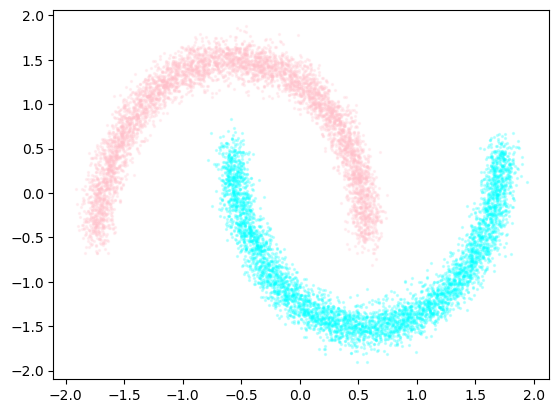

In [12]:
class Moons(Dataset):
    def __init__(self, npoints:int, noise_level:float, device):
        super().__init__()
        data, label = make_moons(n_samples=npoints, noise=noise_level, random_state=2026)
        # Standardize dataset (z-score)
        self.data = self.standardize(torch.tensor(data, dtype=torch.float32, device=device))
        self.label = torch.tensor(label, dtype=torch.float32, device=device)

    def standardize(self, x):
        return (x - x.mean(dim = 0, keepdim=True)) / x.std(dim = 0, keepdim=True)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        return self.data[index,:], self.label[index]
    
MOONS = Moons(npoints=10000, noise_level=0.06, device= DEVICE)
MoonLoader = DataLoader(MOONS, batch_size=2000, shuffle=True)

def plot_moons(samples = None):
    x, y  = MOONS.data.T.cpu()
    lbls = MOONS.label.cpu()
    plt.scatter(x[lbls == 1], y[lbls == 1], color = 'cyan', s = 2, alpha=0.2)
    plt.scatter(x[lbls == 0], y[lbls == 0], color = 'pink', s = 2, alpha=0.2)
    if samples is not None:
        sampx, sampy = samples.T.cpu() 
        plt.scatter(sampx, sampy, color = 'green', s = 2, alpha=1)
    plt.show()

plot_moons()

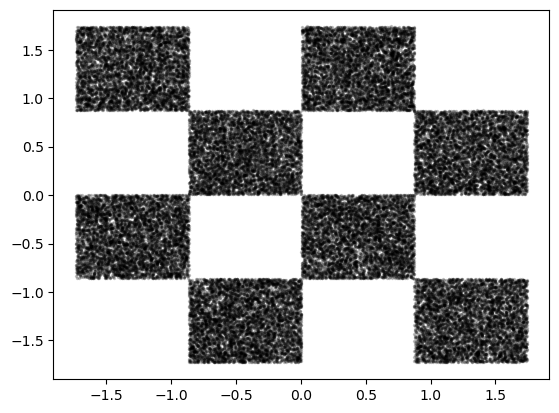

In [25]:
import numpy as np
class Checkers(Dataset):
    def __init__(self, npoints:int, nrowcols:int, device):
        super().__init__()
        data = self.make_checkers(n_points=npoints, n = nrowcols)
        # Standardize dataset (z-score)
        self.data = self.standardize(torch.tensor(data, dtype=torch.float32, device=device))

    def make_checkers(self, n_points, n, n_classes = 2):
        x = np.random.uniform(-(n//2)*np.pi, (n//2)*np.pi, size=(n_points, n_classes))
        mask = np.logical_or(np.logical_and(np.sin(x[:,0]) > 0.0, np.sin(x[:,1]) > 0.0), \
                             np.logical_and(np.sin(x[:,0]) < 0.0, np.sin(x[:,1]) < 0.0))
        y = np.eye(n_classes)[1*mask]
        x = x[y[:,0]==1, :]
        return x

    def standardize(self, x):
        return (x - x.mean(dim = 0, keepdim=True)) / x.std(dim = 0, keepdim=True)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, index):
        return self.data[index,:], ''

CHECK = Checkers(npoints=100000, nrowcols=4, device= DEVICE)
CheckLoader = DataLoader(CHECK, batch_size=2000, shuffle=True)

def plot_checkers(samples = None):
    x, y  = CHECK.data.T.cpu()
    plt.scatter(x, y, color = 'k', s = 2, alpha=0.2)
    if samples is not None:
        sampx, sampy = samples.T.cpu() 
        plt.scatter(sampx, sampy, color = 'gold', s = 2, alpha=1)
    plt.show()

plot_checkers()

In [6]:
class PointWiseMLP(nn.Module):
    '''
    Flow Matching:
        MLP that predicts the vector field toward the target for each interpolant
    Variational Flow Matching:
        MLP that predicts the expectation of the variational distribution 
        over trajectory targets for each interpolant
        NOTE: could also output a true variational distribution (mu, sigma). This allows:
            1) train with Gaussian NLL to actually learn conditional distributions not just expectations over endpoints
            2) at sampling time, instead of deterministically using mu, 
                sample from learned variational distribution over endpoints N(µ, ∑) 
                more varied samples, which should still remain on target manifold
    
    Same MLP with same input can be used but training objective and sampling looks different between FM & VFM
    (if mean and ∑ are output by VFM, then the output differs)
    '''
    def __init__(self, dim:int = 2, nlayers:int = 4, hidden_expansion:int = 2, out:int = 2):
        super().__init__()
        assert (out == dim) or (out == 2*dim), ('Output can be:\n' +
        '1) Vector field (FM, in=out)\n' + 
        '2) Variational expectation over endpoints (VFM, in = out)\n' +
        '3) Variational distribution over endpoints (VFM, out = 2*in, because predicting mu, logstd for each dim)')
        # sequence of MLP layers
        layers = []
        in_dim = dim + 1 # condition on time as well
        for l in range(nlayers):
            out_dim = hidden_expansion * in_dim if l < nlayers // 2 else (in_dim // hidden_expansion 
                                                                          if l != nlayers-1 else out)
            layers.append(nn.Linear(in_dim, out_dim))
            if l < nlayers-1:
                layers.append(nn.LayerNorm(out_dim))
                layers.append(nn.GELU())
                in_dim = out_dim
            else:
                # final layer to project to vector field dimensions
                assert out_dim == out, f'{out_dim}, {out}'
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        '''
        XXX Conditioned on t!!!
        '''
        x = self.net(torch.cat((x, t), dim = -1))
        return x

# Flow Matching

In [7]:
def trainFM(model:PointWiseMLP, X1:DataLoader, epochs:int = 20, lr:float = 5e-4):
    '''
    Flow-Matching training loop for Continuous Normalizing Flow
        Predict vector field
    '''
    optimizer = optim.Adam(model.parameters(), lr)
    objective = nn.MSELoss()
    model.to(DEVICE)
    model.train()
    for e in range(epochs):
        l = 0
        for x1, _ in X1:
            n, d = x1.shape
            optimizer.zero_grad()
            # sample time uniformly U(0,1)
            T = torch.rand(n, device=x1.device)
            # sample starting points randomly from Gaussian N(0,1)
            X0 = torch.randn_like(x1, device=x1.device)
            # Interpolant
            Xt = ((1-T)[:, None] * X0) + (T[:, None]*x1)
            # Predicted Vector field
            Vtheta = model(Xt, T[:, None])
            # GT Vector field (straight line continuation)
            V = (x1 - Xt) / (1 - T)[:, None]
            # Loss: MSE Ground truth vs predicted vector field
            loss = objective(Vtheta, V)
            loss.backward()
            optimizer.step()
            l += loss

        print(f'Epoch {e}, loss: {l / len(X1)}')

def sampleFM(nsamples:int, dt:float, model:PointWiseMLP, dim:int = 2)->torch.Tensor:
    with torch.no_grad():
        model.eval()
        T = torch.arange(0,1, dt, device=DEVICE)
        # at t=0 start with gaussian noise
        xt = torch.randn((nsamples, dim), device=DEVICE)
        for t in T:
            # get vector field
            t_samples = t.expand(nsamples, 1)
            vt = model(xt, t_samples)
            # move along vector field (integrate ODE)
            xt += (vt * dt)
        return xt


Epoch 0, loss: 2.168649196624756
Epoch 1, loss: 1.973699927330017
Epoch 2, loss: 1.9343664646148682
Epoch 3, loss: 1.8925611972808838
Epoch 4, loss: 1.8801448345184326
Epoch 5, loss: 1.8295608758926392
Epoch 6, loss: 1.784600019454956
Epoch 7, loss: 1.7627553939819336
Epoch 8, loss: 1.7158253192901611
Epoch 9, loss: 1.6902555227279663
Epoch 10, loss: 1.684596061706543
Epoch 11, loss: 1.6807372570037842
Epoch 12, loss: 1.6654962301254272
Epoch 13, loss: 1.6434013843536377
Epoch 14, loss: 1.6249080896377563
Epoch 15, loss: 1.6087754964828491
Epoch 16, loss: 1.597297191619873
Epoch 17, loss: 1.5960183143615723
Epoch 18, loss: 1.554641842842102
Epoch 19, loss: 1.5532487630844116
Epoch 20, loss: 1.5073672533035278
Epoch 21, loss: 1.4996744394302368
Epoch 22, loss: 1.466190218925476
Epoch 23, loss: 1.4655287265777588
Epoch 24, loss: 1.4686439037322998
Epoch 25, loss: 1.459520697593689
Epoch 26, loss: 1.4774678945541382
Epoch 27, loss: 1.4586756229400635
Epoch 28, loss: 1.4473800659179688
Epo

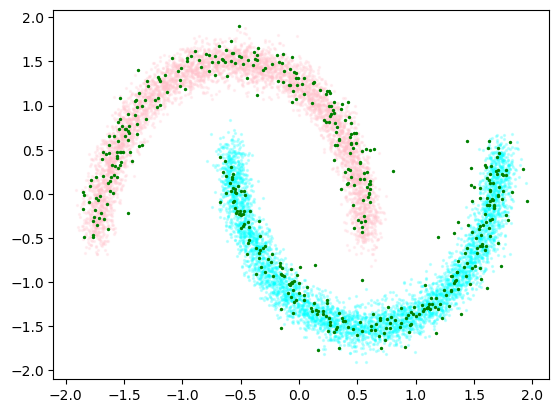

In [15]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4)
trainFM(model=mlp, epochs=100, X1 = MoonLoader, lr=5e-3)
FMsamples = sampleFM(nsamples=500, dt = 1e-4, model = mlp)
plot_moons(FMsamples)
del mlp, FMsamples

Epoch 0, loss: 2.032954216003418
Epoch 1, loss: 1.9951304197311401
Epoch 2, loss: 1.9994208812713623
Epoch 3, loss: 2.0041139125823975
Epoch 4, loss: 2.0012261867523193
Epoch 5, loss: 1.9805002212524414
Epoch 6, loss: 1.856508731842041
Epoch 7, loss: 1.7896602153778076
Epoch 8, loss: 1.7561579942703247
Epoch 9, loss: 1.7575328350067139
Epoch 10, loss: 1.7452020645141602
Epoch 11, loss: 1.6923494338989258
Epoch 12, loss: 1.666865587234497
Epoch 13, loss: 1.6607489585876465
Epoch 14, loss: 1.6257649660110474
Epoch 15, loss: 1.6091963052749634
Epoch 16, loss: 1.5939539670944214
Epoch 17, loss: 1.5596210956573486
Epoch 18, loss: 1.5360180139541626
Epoch 19, loss: 1.5264160633087158
Epoch 20, loss: 1.5120031833648682
Epoch 21, loss: 1.5132652521133423
Epoch 22, loss: 1.5153553485870361
Epoch 23, loss: 1.5104565620422363
Epoch 24, loss: 1.499751091003418
Epoch 25, loss: 1.5010859966278076
Epoch 26, loss: 1.502449631690979
Epoch 27, loss: 1.5109541416168213
Epoch 28, loss: 1.499592900276184
E

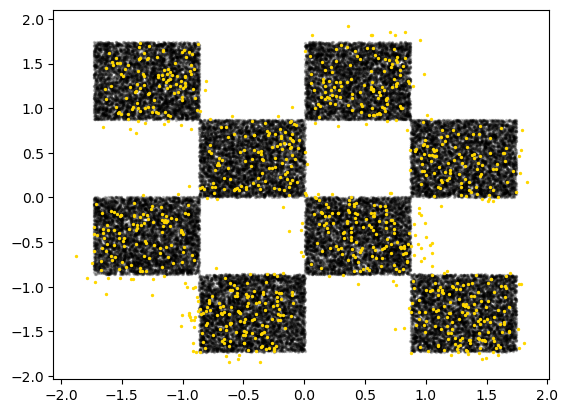

In [33]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4)
trainFM(model=mlp, epochs=100, X1 = CheckLoader, lr=5e-3)
FMsamples = sampleFM(nsamples=1000, dt = 1e-4, model = mlp)
plot_checkers(FMsamples)
del mlp, FMsamples

In [27]:
import gc
# reset for Mean-Field VFM
torch.mps.empty_cache()
gc.collect()

3755

# Mean-Field Variational Flow Matching

In [17]:
def trainVFM_mean(model:PointWiseMLP, X1:DataLoader, epochs:int = 20, lr:float = 5e-4):
    '''
    Variational Flow-Matching training loop for Continuous Normalizing Flow
        Predict variational expectation over vector field targets, construct vector field post-hoc
    '''
    optimizer = optim.Adam(model.parameters(), lr)
    objective = nn.MSELoss()
    model.to(DEVICE)
    model.train()
    for e in range(epochs):
        l = 0
        for x1, _ in X1:
            n, d = x1.shape
            optimizer.zero_grad()
            # sample time uniformly U(0,1)
            T = torch.rand(n, device=x1.device)
            # sample starting points randomly from Gaussian N(0,1)
            X0 = torch.randn_like(x1, device=x1.device)
            # Interpolant
            Xt = ((1-T)[:, None] * X0) + (T[:, None]*x1)
            # Expectation (mu_theta) over Predicted Variational distribution q_theta over vector endpoints
            mu_theta = model(Xt, T[:, None])
            # Loss: MSE - Ground truth Target vs Expectation of Variational Dist over target
            loss = objective(mu_theta, x1)
            loss.backward()
            optimizer.step()
            l+=loss

        print(f'Epoch {e}, loss: {l / len(X1)}')

def sampleVFM_mean(nsamples:int, dt:float, model:PointWiseMLP, dim:int = 2)->torch.Tensor:
    with torch.no_grad():
        model.eval()
        eps = 1e-3
        T = torch.arange(0,1, dt, device=DEVICE) * (1-eps)
        # at t=0 start with gaussian noise
        xt = torch.randn((nsamples, dim), device=DEVICE)
        for t in T:
            # get expectation of variational dist over targets
            t_samples = t.expand(nsamples, 1)
            mu_t = model(xt, t_samples)
            # Construct vector field
            vt = (mu_t - xt) / (1-t+eps)
            # move along vector field (integrate ODE)
            xt += (vt * dt)
        return xt

Epoch 0, loss: 0.9222872853279114
Epoch 1, loss: 0.7620927095413208
Epoch 2, loss: 0.7375935912132263
Epoch 3, loss: 0.7119156718254089
Epoch 4, loss: 0.6861374974250793
Epoch 5, loss: 0.6535270810127258
Epoch 6, loss: 0.6406117081642151
Epoch 7, loss: 0.6265032291412354
Epoch 8, loss: 0.6097444295883179
Epoch 9, loss: 0.6103650331497192
Epoch 10, loss: 0.6074163317680359
Epoch 11, loss: 0.5872710943222046
Epoch 12, loss: 0.5874723196029663
Epoch 13, loss: 0.574069619178772
Epoch 14, loss: 0.5638480186462402
Epoch 15, loss: 0.5459041595458984
Epoch 16, loss: 0.5315560698509216
Epoch 17, loss: 0.5098387002944946
Epoch 18, loss: 0.4916045069694519
Epoch 19, loss: 0.4953010678291321
Epoch 20, loss: 0.4884835183620453
Epoch 21, loss: 0.4852845072746277
Epoch 22, loss: 0.4911154806613922
Epoch 23, loss: 0.4862339496612549
Epoch 24, loss: 0.5017625689506531
Epoch 25, loss: 0.488320529460907
Epoch 26, loss: 0.4897119402885437
Epoch 27, loss: 0.48651647567749023
Epoch 28, loss: 0.4761342108249

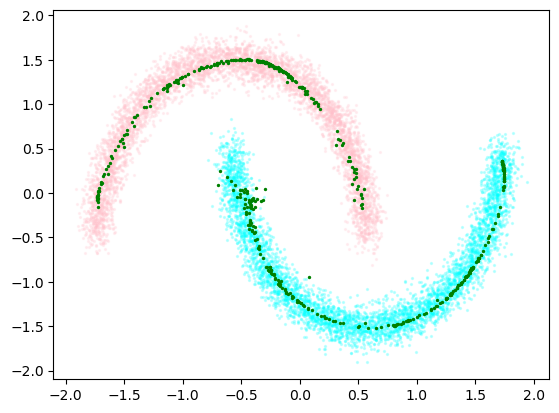

In [18]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4)
trainVFM_mean(model=mlp, epochs=100, X1 = MoonLoader, lr=5e-3)
meanVFMsamples = sampleVFM_mean(nsamples=500, dt = 1e-4, model = mlp)
plot_moons(meanVFMsamples)
del mlp, meanVFMsamples

Epoch 0, loss: 0.8135908246040344
Epoch 1, loss: 0.6531141400337219
Epoch 2, loss: 0.6379640102386475
Epoch 3, loss: 0.5792624354362488
Epoch 4, loss: 0.526958703994751
Epoch 5, loss: 0.5043651461601257
Epoch 6, loss: 0.5020121932029724
Epoch 7, loss: 0.4951474070549011
Epoch 8, loss: 0.5007669925689697
Epoch 9, loss: 0.49722710251808167
Epoch 10, loss: 0.5000011324882507
Epoch 11, loss: 0.4955469071865082
Epoch 12, loss: 0.4966435134410858
Epoch 13, loss: 0.49172863364219666
Epoch 14, loss: 0.49612194299697876
Epoch 15, loss: 0.49755173921585083
Epoch 16, loss: 0.49474966526031494
Epoch 17, loss: 0.4985744059085846
Epoch 18, loss: 0.4938215911388397
Epoch 19, loss: 0.49849602580070496
Epoch 20, loss: 0.4998479187488556
Epoch 21, loss: 0.49715057015419006
Epoch 22, loss: 0.5008973479270935
Epoch 23, loss: 0.4994543790817261
Epoch 24, loss: 0.5005919337272644
Epoch 25, loss: 0.4972698986530304
Epoch 26, loss: 0.49919623136520386
Epoch 27, loss: 0.4932466447353363
Epoch 28, loss: 0.49620

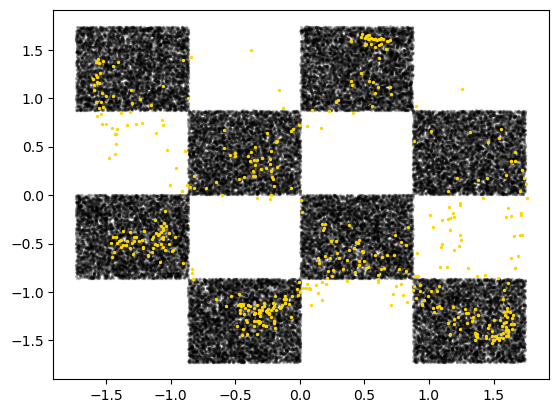

In [28]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4)
trainVFM_mean(model=mlp, epochs=100, X1 = CheckLoader, lr=5e-3)
meanVFMsamples = sampleVFM_mean(nsamples=500, dt = 1e-4, model = mlp)
plot_checkers(meanVFMsamples)
del mlp, meanVFMsamples

# General Variational Flow Matching

In [31]:
import math
def gaussian_nll(x, mu, log_sigma, clamp=(-10, 10)):
    '''
    Maximize log N(x1 | µ_theta, ∑_theta) = Minimize - log N(x1 | µ_theta, ∑_theta)
    '''
    # x, mu, log_sigma: (B, D)
    log_sigma = log_sigma.clamp(*clamp)
    log_var = 2.0 * log_sigma
    inv_var = torch.exp(-log_var)  # 1/var

    nll = 0.5 * ((x - mu)**2 * inv_var + log_var + math.log(2.0 * math.pi))
    return nll.mean()

def trainVFM(model:PointWiseMLP, X1:DataLoader, epochs:int = 20, lr:float = 5e-4):
    '''
    General Variational Flow-Matching training loop for Continuous Normalizing Flow
        Predict variational distribution (mu, sigma) over vector field targets, construct vector field post-hoc
    '''
    optimizer = optim.Adam(model.parameters(), lr)
    objective = gaussian_nll
    model.to(DEVICE)
    model.train()
    for e in range(epochs):
        l = 0
        for x1, _ in X1:
            n, d = x1.shape
            optimizer.zero_grad()
            # sample time uniformly U(0,1)
            T = torch.rand(n, device=x1.device)
            # sample starting points randomly from Gaussian N(0,1)
            X0 = torch.randn_like(x1, device=x1.device)
            # Interpolant
            Xt = ((1-T)[:, None] * X0) + (T[:, None]*x1)
            # Expectation (mu_theta) and logSTD of Predicted Variational distribution q_theta over vector endpoints
            q_theta = model(Xt, T[:, None])
            mu_theta, logstd_theta = q_theta.chunk(2, dim = -1)
            # Loss: Gaussian NLL
            loss = objective(x = x1, mu=mu_theta, log_sigma=logstd_theta)
            loss.backward()
            optimizer.step()
            l+= loss

        print(f'Epoch {e}, loss: {l/len(X1)}')

def sampleVFM(nsamples:int, dt:float, model:PointWiseMLP, dim:int = 2, 
              stochastic:bool = False)->torch.Tensor:
    with torch.no_grad():
        model.eval()
        eps = 1e-3
        T = torch.arange(0,1, dt, device=DEVICE) * (1-eps)
        # at t=0 start with gaussian noise
        xt = torch.randn((nsamples, dim), device=DEVICE)
        for t in T:
            # get expectation of variational dist over targets
            t_samples = t.expand(nsamples, 1)
            q_t = model(xt, t_samples)
            mu_t, logstd_t = q_t.chunk(2, dim = -1)
            # Construct vector field using mu_t (follow mean-drift)
            vt = (mu_t - xt) / (1-t + eps)
            # move along vector field (integrate ODE)
            xt += (vt * dt)
        if stochastic:
            # at the end, sample endpoint according to variational dist
            xt += torch.exp(logstd_t.clamp(-10,10)) * torch.randn_like(mu_t)
        return xt

In [17]:
# reset for General VFM
torch.mps.empty_cache()
gc.collect()

1046

Epoch 0, loss: 1.5196887254714966
Epoch 1, loss: 1.4259387254714966
Epoch 2, loss: 1.4200739860534668
Epoch 3, loss: 1.4116175174713135
Epoch 4, loss: 1.3612661361694336
Epoch 5, loss: 1.2948949337005615
Epoch 6, loss: 1.2556378841400146
Epoch 7, loss: 1.2236521244049072
Epoch 8, loss: 1.19623601436615
Epoch 9, loss: 1.1793957948684692
Epoch 10, loss: 1.1576740741729736
Epoch 11, loss: 1.1396410465240479
Epoch 12, loss: 1.105312705039978
Epoch 13, loss: 1.0890862941741943
Epoch 14, loss: 1.0791380405426025
Epoch 15, loss: 1.0822389125823975
Epoch 16, loss: 1.0770487785339355
Epoch 17, loss: 1.0618923902511597
Epoch 18, loss: 1.0406920909881592
Epoch 19, loss: 1.0452064275741577
Epoch 20, loss: 1.0423619747161865
Epoch 21, loss: 1.0213418006896973
Epoch 22, loss: 1.0194450616836548
Epoch 23, loss: 1.0393102169036865
Epoch 24, loss: 1.01688551902771
Epoch 25, loss: 1.0218394994735718
Epoch 26, loss: 0.9948552250862122
Epoch 27, loss: 0.9990392923355103
Epoch 28, loss: 0.98405522108078
Ep

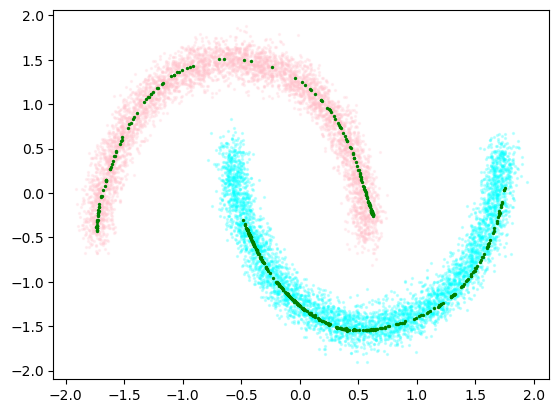

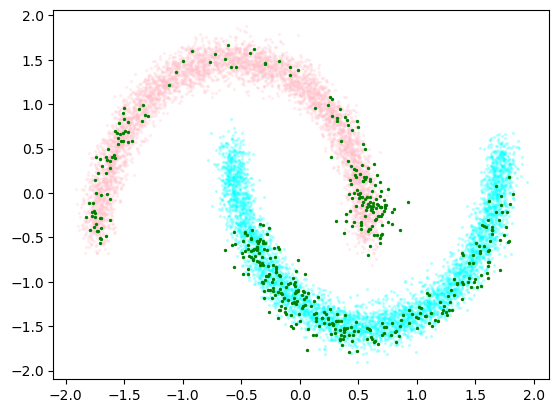

In [20]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4, out = 4)
trainVFM(model=mlp, epochs=100, X1 = MoonLoader, lr=5e-3)
VFMsamples = sampleVFM(nsamples=500, dt = 1e-4, model = mlp, stochastic=False)
plot_moons(VFMsamples)
VFMsamples = sampleVFM(nsamples=500, dt = 1e-4, model = mlp, stochastic=True)
plot_moons(VFMsamples)
del mlp, VFMsamples

Epoch 0, loss: 1.4445538520812988
Epoch 1, loss: 1.4190964698791504
Epoch 2, loss: 1.4178351163864136
Epoch 3, loss: 1.3819859027862549
Epoch 4, loss: 1.319064736366272
Epoch 5, loss: 1.257927417755127
Epoch 6, loss: 1.2516227960586548
Epoch 7, loss: 1.2464723587036133
Epoch 8, loss: 1.2428405284881592
Epoch 9, loss: 1.2436968088150024
Epoch 10, loss: 1.242049217224121
Epoch 11, loss: 1.2431678771972656
Epoch 12, loss: 1.2427247762680054
Epoch 13, loss: 1.2405565977096558
Epoch 14, loss: 1.2387044429779053
Epoch 15, loss: 1.241184115409851
Epoch 16, loss: 1.2369486093521118
Epoch 17, loss: 1.2339303493499756
Epoch 18, loss: 1.2340983152389526
Epoch 19, loss: 1.2323815822601318
Epoch 20, loss: 1.2314743995666504
Epoch 21, loss: 1.229683518409729
Epoch 22, loss: 1.2253226041793823
Epoch 23, loss: 1.2199575901031494
Epoch 24, loss: 1.2190361022949219
Epoch 25, loss: 1.2115579843521118
Epoch 26, loss: 1.207179069519043
Epoch 27, loss: 1.1993393898010254
Epoch 28, loss: 1.200898289680481
Ep

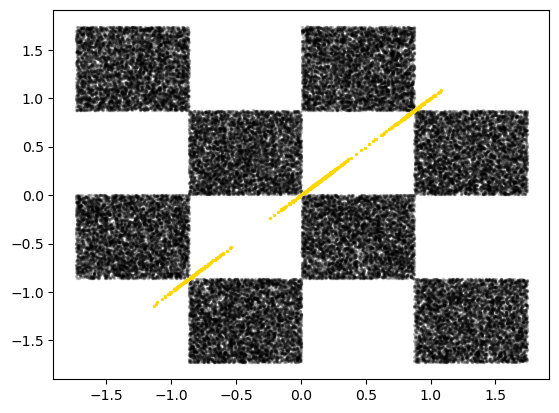

In [32]:
mlp = PointWiseMLP(nlayers=10, hidden_expansion=4)
trainVFM(model=mlp, epochs=100, X1 = CheckLoader, lr=5e-3)
# VFMsamples = sampleVFM(nsamples=500, dt = 1e-4, model = mlp)
# plot_checkers(VFMsamples)
VFMsamples = sampleVFM(nsamples=500, dt = 1e-4, model = mlp, stochastic=True)
plot_checkers(VFMsamples)
del mlp, VFMsamples

collapses to easiest overall transport direction from N(0,I) to dataset